<div dir="rtl" style="text-align: right;">

#  تمرین پنجم درس یادگیری عمیق


این فایل برای راحتی شما تهیه شده (امیدواریم اینطور باشه) اما اگه اینشکلی به نظرتون نمیاد لطفا همونطور که صلاح میدونید انجام بدید. اگه جایی از سلول ها مشکل داره میتونید اصلاح کنید اما دلیلش رو هم به صورت کامنت توضیح بدید.
</div>

<div dir='rtl'>

# بخش اول

</div>

<div dir="rtl" style="text-align: right;">

##  شمارش تصاویر دیتاست

در این بخش قصد داریم تعداد تصاویر موجود در پوشه‌ی دیتاست را محاسبه کنیم.

پوشه‌ای با نام `50k` در اختیار شما قرار گرفته است که شامل تعداد زیادی تصویر با پسوند `.jpg` است. هدف شما این است که:

<ul>
    <li>با استفاده از کتابخانه <code>pathlib</code> مسیر پوشه را مشخص کنید.</li>
    <li>تمام فایل‌های با پسوند <code>.jpg</code> را در تمامی زیرپوشه‌ها پیدا کنید.</li>
    <li>تعداد کل این تصاویر را محاسبه کنید.</li>
    <li>تعداد نهایی را در متغیر <code>num_images</code> ذخیره نمایید.</li>
</ul>

<strong>نکته:</strong> برای جستجوی بازگشتی در زیرپوشه‌ها می‌توانید از تابع
<code>rglob()</code> استفاده کنید.

</div>

In [16]:
### START CODE HERE ###
from pathlib import Path

path = Path("50k")

# Finding all jpg files in the directory and its subdirectories
all_images = list(path.rglob('*.jpg'))
num_images = len(all_images)

### END CODE HERE ###

print(f"Number of jpg files: {num_images}")


# --- HOMELANDER: DON'T TOUCH IT!!
test_dataset_count = num_images


Number of jpg files: 50000


<div dir="rtl" style="text-align: right;">

##  نمایش نمونه‌هایی از دیتاست

قبل از شروع آموزش مدل، بهتر است نگاهی به تصاویر موجود در دیتاست بیندازیم. این کار به ما کمک می‌کند تا:

<ul>
    <li>از سالم بودن تصاویر اطمینان حاصل کنیم.</li>
    <li>تنوع داده‌ها را بررسی کنیم.</li>
    <li>با ظاهر کلی دیتاست آشنا شویم.</li>
</ul>

در این تمرین باید:

<ol>
    <li>یک شکل شامل ۲ سطر و ۵ ستون ایجاد کنید.</li>
    <li>در هر خانه، یک تصویر تصادفی از لیست <code>all_images</code> نمایش دهید.</li>
    <li>نام فایل هر تصویر را به عنوان عنوان آن نمایش دهید.</li>
    <li>محورهای نمودار را مخفی کنید تا تصاویر واضح‌تر دیده شوند.</li>
</ol>

<strong>راهنمایی:</strong> می‌توانید از تابع
<code>random.choice()</code>
برای انتخاب تصادفی تصاویر استفاده کنید.

</div>

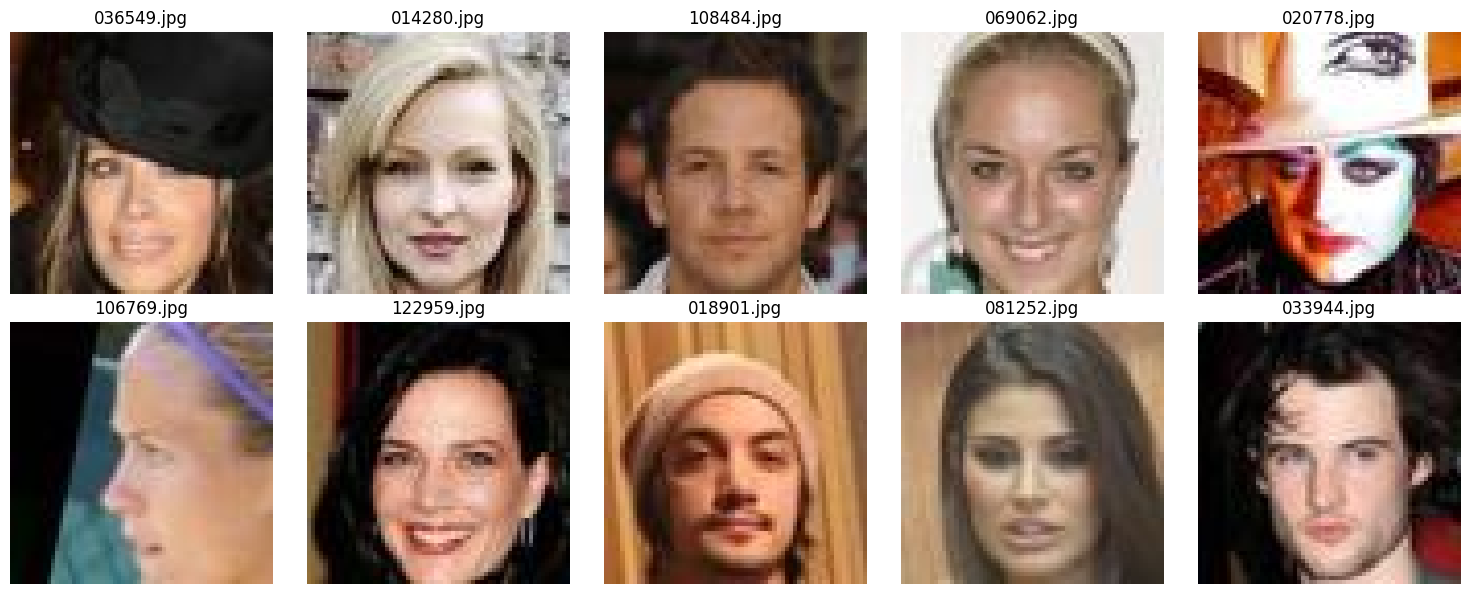

In [17]:
import matplotlib.pyplot as plt
import random

### START CODE HERE ###

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax in axes.flatten():
    img_path = random.choice(all_images)

    img = plt.imread(img_path)

    ax.imshow(img)
    ax.set_title(img_path.name)
    ax.axis("off")

### END CODE HERE ###


plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right;">

##  تنظیم Seed و انتخاب دستگاه اجرا

برای اینکه نتایج آزمایش‌های یادگیری ماشین قابل بازتولید (Reproducible) باشند، معمولاً مقدار ثابتی برای مولد اعداد تصادفی تعیین می‌کنیم. این کار باعث می‌شود که در اجرای مجدد نوت‌بوک، عملیات تصادفی مانند مقداردهی اولیه وزن‌ها یا نمونه‌گیری تصادفی نتایج یکسانی تولید کنند.

در این تمرین باید:

<ul>
    <li>دستگاه اجرا را مشخص کنید.</li>
    <li>اگر GPU در دسترس بود از آن استفاده کنید؛ در غیر این صورت از CPU استفاده نمایید.</li>
    <li>Seed مربوط به کتابخانه‌های مختلف را مقداردهی کنید.</li>
    <li>در صورت استفاده از CUDA، Seed مربوط به تمام GPUها را نیز تنظیم نمایید.</li>
</ul>

<strong>نکته:</strong>
برای بررسی در دسترس بودن GPU می‌توانید از تابع
<code>torch.cuda.is_available()</code>
استفاده کنید.

</div>

In [18]:
import random
import torch
import numpy as np

SEED = 42

### START CODE HERE ###

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

### END CODE HERE ###


print("Seed fixed.")
print("Using device:", device)

Seed fixed.
Using device: cpu


<div dir='rtl'>

<h2>
 تقسیم‌بندی مجموعه‌داده (Train, Validation, Test Split)
</h2>
در این بخش، شما باید لیست تمامی مسیرهای تصاویر (all_images) را به سه قسمت تقسیم کنید:

<ul>
    <li>
        آموزش (Train): ۸۰٪ از کل داده‌ها برای آموزش مدل.
    </li>
    <li>
        ارزیابی (Validation): ۱۰٪ از کل داده‌ها برای تنظیم هایپرپارامترها و جلوگیری از Overfitting.
    </li>
    <li>
        آزمایش (Test): ۱۰٪ باقی‌مانده برای سنجش نهایی دقت مدل.
    </li>
</ul>

<strong>
راهنمایی:
</strong>

<ol>
    <li>
از تابع train_test_split کتابخانه sklearn استفاده کنید.
    </li>
    <li>
ابتدا داده‌ها را به ۸۰٪ آموزش و ۲۰٪ موقت (temp) تقسیم کنید.
    </li>
    <li>
سپس داده‌های موقت را به نسبت ۵۰/۵۰ تقسیم کنید تا ۱۰٪ اعتبار‌سنجی و ۱۰٪ تست به دست آید.
    </li>
    <li>
حتماً از متغیر SEED برای پارامتر random_state استفاده کنید تا نتایج قابل بازتولید باشند.
    </li>
</ol>

</div>

In [19]:
from sklearn.model_selection import train_test_split

SEED = 42

### START CODE HERE (2-10 lines of code)
train_paths, temp_paths = train_test_split(all_images, test_size=0.2, random_state=SEED)

val_paths, test_paths = train_test_split(temp_paths, test_size=0.5, random_state=SEED)
### END CODE HERE

if train_paths is not None:
    print("Train:", len(train_paths))
    print("Val:", len(val_paths))
    print("Test:", len(test_paths))



# --- HOMELANDER: DON'T TOUCH IT!!
if train_paths:
    test_train_count = len(train_paths)
    test_val_count = len(val_paths)
    test_test_count = len(test_paths)
    test_split_seed = SEED


Train: 40000
Val: 5000
Test: 5000


<div dir='rtl'>
    <h2>
     پیش‌پردازش و تبدیل تصاویر (Image Transformations)
    </h2>
<p>
در این بخش، شما باید transformهای لازم برای آماده‌سازی تصاویر را تعریف کنید. تصاویر ورودی دارای ابعاد متفاوتی هستند، اما برای ورود به شبکه عصبی باید همگی به اندازه ثابت 64x64 تغییر سایز داده شوند.
</p>
    <strong>
    نیازمندی‌ها:
    </strong>

<ol>
        <li>
        آموزش (train_transform):
            <ul>
                <li>
                تغییر اندازه (Resize) به ابعاد IMAGE_SIZE.
                </li>
                <li>
                چرخش افقی تصادفی (RandomHorizontalFlip) با احتمال ۵۰٪ برای بهبود تعمیم‌پذیری مدل.
                </li>
                <li>
                تبدیل به تنسور (ToTensor).
                </li>
            </ul>
        </li>
        <li>
        تست و اعتبار‌سنجی (test_transform):
            <ul>
                <li>
                فقط تغییر اندازه (Resize) و تبدیل به تنسور (ToTensor) بدون هیچ‌گونه Augmentation.
                </li>
            </ul>
        </li>
    </ol>
</div>

In [20]:
from torchvision import transforms

IMAGE_SIZE = 64


### START CODE HERE ###

train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])
test_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor()
])

### END CODE HERE ###


# --- HOMELANDER: DON'T TOUCH IT!!
if IMAGE_SIZE:
    test_image_size = IMAGE_SIZE
    test_train_transform_names = [type(t).__name__ for t in train_transform.transforms]
    test_test_transform_names = [type(t).__name__ for t in test_transform.transforms]
    test_train_flip_p = train_transform.transforms[1].p


<div dir='rtl'>

## ساخت کلاس Dataset برای CelebA

در این بخش می‌خواهیم یک کلاس سفارشی برای دیتاست CelebA بسازیم.

در PyTorch، برای ساخت دیتاست سفارشی معمولاً از کلاس `Dataset` ارث‌بری می‌کنیم و سه بخش اصلی را پیاده‌سازی می‌کنیم:

1. `__init__`
   - مسیر تصاویر را دریافت و ذخیره می‌کند.
   - transformهای مربوط به پیش‌پردازش تصویر را ذخیره می‌کند.

2. `__len__`
   - تعداد کل تصاویر موجود در دیتاست را برمی‌گرداند.

3. `__getitem__`
   - با گرفتن یک اندیس `idx`، مسیر تصویر مربوطه را پیدا می‌کند.
   - تصویر را با `PIL.Image` باز می‌کند.
   - تصویر را به حالت `RGB` تبدیل می‌کند.
   - اگر transform تعریف شده باشد، آن را روی تصویر اعمال می‌کند.
   - در نهایت تصویر پردازش‌شده را برمی‌گرداند.

در این تمرین باید کلاس `CelebADataset` را کامل کنید تا بتوانیم بعداً از آن برای ساخت `DataLoader` استفاده کنیم.

</div>

In [21]:
from torch.utils.data import Dataset
from PIL import Image

class CelebADataset(Dataset):
    def __init__(self, image_paths, transform=None):
        """
        Args:
            image_paths: list of image file paths
            transform: torchvision transforms applied to each image
        """
        ### START CODE HERE ###
        self.image_paths = image_paths
        self.transform = transform
        ### END CODE HERE ###

    def __len__(self):
        """
        Return the number of images in the dataset.
        """
        ### START CODE HERE ###
        return len(self.image_paths)
        ### END CODE HERE ###

    def __getitem__(self, idx):
        """
        Load one image, convert it to RGB, apply transform if available,
        and return the image.
        """
        ### START CODE HERE ###
        path = self.image_paths[idx]

        image = Image.open(path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image

         ### END CODE HERE ###

<div dir='rtl'>

## ساخت Dataset برای داده‌های آموزش، اعتبارسنجی و آزمون

اکنون که کلاس `CelebADataset` را پیاده‌سازی کرده‌اید، باید از آن برای ساخت سه دیتاست جداگانه استفاده کنید:

- `train_dataset`
- `val_dataset`
- `test_dataset`

در این مرحله باید:

1. برای داده‌های آموزش از `train_paths` و `train_transform` استفاده کنید.
2. برای داده‌های اعتبارسنجی از `val_paths` و `test_transform` استفاده کنید.
3. برای داده‌های آزمون از `test_paths` و `test_transform` استفاده کنید.

توجه کنید که:
- روی داده‌های آموزش از `train_transform` استفاده می‌کنیم، چون ممکن است شامل data augmentation باشد.
- روی داده‌های اعتبارسنجی و آزمون از `test_transform` استفاده می‌کنیم، چون این بخش‌ها باید بدون augmentation و فقط با پیش‌پردازش ثابت انجام شوند.

وظیفه شما در این سلول این است که هر سه دیتاست را با استفاده از کلاس `CelebADataset` مقداردهی کنید.

</div>


In [22]:
### START CODE HERE

train_dataset = CelebADataset(image_paths=train_paths, transform=train_transform)

val_dataset = CelebADataset(image_paths=val_paths, transform=test_transform)

test_dataset = CelebADataset(image_paths=test_paths, transform=test_transform)

### END CODE HERE

# --- HOMELANDER: HEY JUST TO BE CLEAR, DON'T EVER NEVER LOOK AT THIS OKAY?? YEAH ADABODY
test_dataset_class_train_len = len(train_dataset)
test_dataset_class_val_len = len(val_dataset)
test_dataset_class_test_len = len(test_dataset)


<div dir='rtl'>

## ایجاد DataLoader برای مدیریت دسته‌ای داده‌ها (Batching)

پس از آماده‌سازی دیتاست‌ها، گام بعدی استفاده از `DataLoader` برای دسته‌بندی تصاویر است. `DataLoader` به ما اجازه می‌دهد داده‌ها را به صورت دسته‌ای (Batch) به مدل تزریق کنیم، آن‌ها را در هر Epoch مخلوط (Shuffle) کنیم و از پردازش موازی برای بارگذاری داده‌ها استفاده کنیم.

در این بخش باید:
1. متغیر `BATCH_SIZE` را تنظیم کنید (مقدار پیشنهادی: 64).
2. سه نمونه `DataLoader` برای مجموعه‌های `train` ،`val` و `test` بسازید.

**نکات مهم:**
- برای `train_loader` حتماً `shuffle=True` قرار دهید تا مدل ترتیب تصاویر را حفظ نکند.
- برای `val_loader` و `test_loader` معمولاً `shuffle=False` قرار می‌دهیم تا ارزیابی روی یک ترتیب ثابت انجام شود.
- متغیر `num_workers` را برای سادگی فعلاً 0 قرار می‌دهیم (مخصوصاً در محیط‌های ویندوز یا سیستم‌های ضعیف).


</div>

In [23]:
from torch.utils.data import DataLoader


### START CODE HERE ###
# Set the batch size
BATCH_SIZE = 64

# For simplicity on most machines, set num_workers to 0
NUM_WORKERS = 2

# Initialize the DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
### END CODE HERE ###

# Print information
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader) if train_loader is not None else 0}")
print(f"Val batches: {len(val_loader) if val_loader is not None else 0}")
print(f"Test batches: {len(test_loader) if test_loader is not None else 0}")


# --- HOMELANDER: OH BOY YOU CAN'T ESCAPE FROM DESTENY... I FNISH YOU SOON. PROMISE
if BATCH_SIZE:
    test_train_loader_shuffle = train_loader.dataset is not None and train_loader.batch_size == BATCH_SIZE
    test_train_batches_count = len(train_loader)
    test_val_batches_count = len(val_loader)
    test_test_batches_count = len(test_loader)

Batch size: 64
Train batches: 625
Val batches: 79
Test batches: 79


<div dir='rtl'>

## مشاهده یک batch از تصاویر آموزشی

اکنون که `train_loader` را ساخته‌اید، می‌توانیم یک batch از تصاویر را از آن دریافت کرده و چند نمونه را نمایش دهیم.

در این بخش:
- با استفاده از `next(iter(train_loader))` اولین batch از داده‌های آموزشی را می‌گیریم.
- سپس 16 تصویر اول این batch را انتخاب می‌کنیم.
- چون تصاویر در PyTorch معمولاً به صورت `(C, H, W)` ذخیره می‌شوند، برای نمایش با `matplotlib` باید ترتیب ابعاد را به `(H, W, C)` تغییر دهیم. برای این کار از `permute(1, 2, 0)` استفاده می‌کنیم.
- در نهایت تصاویر را در یک شبکه `4×4` نمایش می‌دهیم.

این مرحله یک بررسی دیداری (visual sanity check) مهم است تا مطمئن شویم:
- تصاویر به درستی از `DataLoader` خوانده می‌شوند،
- ابعاد آن‌ها درست است،
- و transformها به شکل مورد انتظار اعمال شده‌اند.


</div>

In [24]:

### START CODE HERE ###
# 1. Get a single batch from the train_loader
images = next(iter(train_loader))

# 2. Plot a grid of 4x4 images
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flatten()):
    # Get the i-th image from the batch
    img = images[i]

    # 3. Permute the dimensions of the image from (C, H, W) to (H, W, C)
    # to be compatible with matplotlib
    img_permuted = img.permute(1, 2, 0)

    # 4. Display the image
    ax.imshow(img_permuted)
    ax.axis("off")
### END CODE HERE ###

plt.tight_layout()
plt.show()

# --- HOMELANDER: WE BOTH HATE THIS UNIVERSITY, ESPECIALY THE NEWCOMERS. RIGHT?!! RIGHT?!!
test_batch_images_shape = list(images.shape) if images is not None else None

Traceback (most recent call last):
  File "<string>", line 1, in <module>
    from multiprocessing.spawn import spawn_main; spawn_main(tracker_fd=106, pipe_handle=103)
                                                  ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: Can't get attribute 'CelebADataset' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>


KeyboardInterrupt: 

<div dir='rtl'>

## بررسی آماری داده‌ها (Data Statistics)

قبل از طراحی و آموزش مدل، باید مطمئن شویم که داده‌ها به درستی پیش‌پردازش شده‌اند. چون از `transforms.ToTensor()` استفاده کرده‌ایم، انتظار داریم مقادیر پیکسل‌ها از بازه $[0, 255]$ به بازه $[0, 1]$ منتقل شده باشند.

در این بخش، یک batch از داده‌ها را استخراج کرده و موارد زیر را بررسی می‌کنیم:
1. **Shape**: ابعاد batch باید به صورت `(Batch_Size, Channels, Height, Width)` باشد.
2. **Min & Max**: حداقل مقدار باید نزدیک به $0$ و حداکثر نزدیک به $1$ باشد.
3. **Mean & Std**: میانگین و انحراف معیار پیکسل‌ها را بررسی می‌کنیم تا دیدی نسبت به توزیع داده‌ها داشته باشیم.

این بررسی به ما کمک می‌کند تا اگر در مراحل قبلی (مثل Transformها) اشتباهی رخ داده باشد، همین‌جا متوجه شویم.


</div>

In [14]:
### START CODE HERE ###
# 1. Get one batch from train_loader
batch = next(iter(train_loader))

# 2. Calculate statistics
batch_shape = batch.shape
batch_min = batch.min().item()
batch_max = batch.max().item()
batch_mean = batch.mean().item()
batch_std = batch.std().item()
### END CODE HERE ###

print(f"Shape: {batch_shape}")
print(f"Min: {batch_min:.4f}")
print(f"Max: {batch_max:.4f}")
print(f"Mean: {batch_mean:.4f}")
print(f"Std: {batch_std:.4f}")

# --- HOMELANDER: BUTCHER!! YOU AGAIN. YOU CAN TOUCH IT BUT FIRST, SAY HELLO TO MY LITTLE FRIEND HAHAHA...
test_stats_shape = list(batch_shape) if batch_shape is not None else []
test_stats_min = float(batch_min) if batch_min is not None else -1.0
test_stats_max = float(batch_max) if batch_max is not None else -1.0


Traceback (most recent call last):
  File "<string>", line 1, in <module>
    from multiprocessing.spawn import spawn_main; spawn_main(tracker_fd=106, pipe_handle=138)
                                                  ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: Can't get attribute 'CelebADataset' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>


KeyboardInterrupt: 

<div dir='rtl'>

## محاسبه میانگین و انحراف معیار کل دیتاست

در مراحل قبلی، آمار یک Batch را بررسی کردیم. اما برای درک بهتر داده‌ها (و احتمالاً نرمال‌سازی دقیق‌تر در پروژه‌های پیشرفته‌تر)، نیاز داریم میانگین و انحراف معیار را روی **کل تصاویر مجموعه آموزش** محاسبه کنیم.

در این بخش شما باید:
1. روی تمام دسته‌ها (Batches) در `train_loader` پیمایش کنید.
2. هر تصویر را که ابعاد آن `(3, 64, 64)` است، به ابعاد `(3, 4096)` تغییر شکل (Reshape) دهید تا محاسبات روی پیکسل‌ها ساده‌تر شود.
3. میانگین و انحراف معیار را برای هر کانال رنگی به صورت تجمعی محاسبه کنید.
4. در نهایت مقادیر تجمعی را بر تعداد کل تصاویر (`n_samples`) تقسیم کنید.

**نکته:** استفاده از `tqdm` برای نمایش نوار پیشرفت (Progress Bar) در حلقه‌های طولانی توصیه می‌شود.


</div>

In [15]:
from tqdm import tqdm
import torch


### START CODE HERE ###
# Initialize tensors to store mean and std for 3 channels
mean = torch.zeros(3)
std = torch.zeros(3)
n_samples = 0

for images in tqdm(train_loader):
    # Get batch size
    batch_size = images.size(0)

    # Reshape images to (batch_size, 3, height * width)
    # Hint: use images.view(batch_size, 3, -1)
    images_flattened = images.view(batch_size, 3, -1)

    # Calculate mean and std per channel for this batch
    # and add to the cumulative variables
    # Hint: mean(dim=2).sum(dim=0)
    mean += images_flattened.mean(dim=2).sum(dim=0)
    std += images_flattened.std(dim=2).sum(dim=0)

    # Update total samples count
    n_samples += batch_size

# Final division to get the average
mean /= n_samples
std /= n_samples
### END CODE HERE ###

print(f"Global Mean: {mean}")
print(f"Global Std: {std}")

# --- HOMELANDER: HEY JUST TO BE CLEAR, DON'T EVER NEVER LOOK AT THIS OKAY?? ADABODY
test_global_mean = mean.tolist() if mean is not None else []
test_global_std = std.tolist() if std is not None else []
test_n_samples = n_samples

  0%|          | 0/625 [00:00<?, ?it/s]Traceback (most recent call last):
  File "<string>", line 1, in <module>
    from multiprocessing.spawn import spawn_main; spawn_main(tracker_fd=106, pipe_handle=156)
                                                  ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: Can't get attribute 'CelebADataset' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>
  0%|          | 0/625 [00:14<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
torch.save(
    {
        "train": [str(p) for p in train_paths],
        "val": [str(p) for p in val_paths],
        "test": [str(p) for p in test_paths],
    },
    "celeba_splits.pt"
)

print("Splits saved.")

Splits saved.


<div dir='rtl'>

## پیاده‌سازی Convolutional Autoencoder

در این بخش، یک Autoencoder کانولوشنی برای تصاویر CelebA طراحی خواهیم کرد. هدف اصلی این مدل، فشرده‌سازی تصویر به یک فضای میانی (Latent Space) و سپس بازسازی مجدد آن است.

ساختار مدل شامل دو بخش است:

### الف) Encoder (رمزگذار)
وظیفه این بخش کاهش ابعاد مکانی تصویر و استخراج ویژگی‌های مهم در قالب یک بردار فشرده (Latent Vector) است.
- **ورودی:** یک تصویر RGB با ابعاد `(3, 64, 64)`.
- **فرایند:** با استفاده از لایه‌های `Conv2d` با `stride=2` و `padding=1` در هر مرحله، طول و عرض تصویر نصف می‌شود.
- **تغییر ابعاد:** مسیر کاهش ابعاد به این صورت است: `64x64` -> `32x32` -> `16x16` -> `8x8` -> `4x4`.
- **خروجی:** در نهایت خروجی لایه‌های کانولوشنی Flatten شده و توسط یک لایه `Linear` به برداری با اندازه `latent_dim` تبدیل می‌شود.

### ب) Decoder (رمزگشا)
وظیفه این بخش، تبدیل بردار فشرده به تصویری است که تا حد ممکن شبیه به ورودی اصلی باشد.
- **ورودی:** بردار `latent_dim`.
- **فرایند:** ابتدا با یک لایه `Linear` بردار را به ابعاد `(256, 4, 4)` برمی‌گردانیم. سپس با استفاده از لایه‌های `ConvTranspose2d` (معکوس کانولوشن)، ابعاد تصویر را مرحله به مرحله افزایش می‌دهیم.
- **تغییر ابعاد:** مسیر افزایش ابعاد: `4x4` -> `8x8` -> `16x16` -> `32x32` -> `64x64`.
- **خروجی:** لایه آخر از تابع فعال‌ساز `Sigmoid` استفاده می‌کند تا مقادیر خروجی حتماً در بازه `[0, 1]` (مشابه ورودی‌های نرمال شده) قرار بگیرند.

**نکته:** استفاده از `BatchNorm2d` و `ReLU` بعد از هر لایه کانولوشنی (به جز لایه آخر) به پایداری و سرعت آموزش مدل کمک می‌کند.


</div>

In [ ]:
import torch
import torch.nn as nn


class ConvAE(nn.Module):
    """
    Convolutional Autoencoder for 64x64 RGB images.

    Arguments:
    latent_dim -- size of the latent representation
    """

    def __init__(self, latent_dim=128):
        super().__init__()

        ### START CODE HERE ###

        # Encoder: input shape (3, 64, 64)
        self.encoder = nn.Sequential(
            # 64 -> 32
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # 32 -> 16
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # 16 -> 8
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # 8 -> 4
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

        )

        # Flattened encoder output should map to latent_dim
        self.fc_enc = nn.Linear(in_features=4096, out_features=latent_dim)

        # Latent vector should map back to flattened feature map
        self.fc_dec = nn.Linear(in_features=latent_dim, out_features=4096)

        # Decoder: reconstruct image back to (3, 64, 64)
        self.decoder = nn.Sequential(
            # 4 -> 8
            nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=4, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # 8 -> 16
            nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=4, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),


            # 16 -> 32
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),


            # 32 -> 64
            nn.ConvTranspose2d(in_channels=32, out_channels=3, kernel_size=4, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()

        )

        ### END CODE HERE ###

    def encode(self, x):
        """
        Encode input images into latent vectors.
        """
        ### START CODE HERE ###
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        z = self.fc_enc(x)
        return z
        ### END CODE HERE ###

    def decode(self, z):
        """
        Decode latent vectors back into images.
        """
        ### START CODE HERE ###
        x = self.fc_dec(z)
        x = x.view(x.size(0), 256, 4, 4)
        x = self.decoder(x)
        return x
        ### END CODE HERE ###

    def forward(self, x):
        """
        Forward pass through the autoencoder.
        """
        ### START CODE HERE ###
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat
        ### END CODE HERE ###

<div dir='rtl'>

### بررسی ساختار و تعداد پارامترهای مدل

پس از پیاده‌سازی کلاس `ConvAE` در سلول قبل، اکنون یک نمونه از این مدل می‌سازیم. بررسی تعداد پارامترهای مدل به ما کمک می‌کند تا مطمئن شویم معماری شبکه بیش از حد سنگین یا بیش از حد ساده نیست.

معمولاً برای دیتاست CelebA با ابعاد ۶۴x۶۴، مدلی با تعداد پارامتر بین **۲ تا ۵ میلیون** مناسب است (بسته به تعداد فیلترهایی که در لایه‌ها انتخاب کرده‌اید).


</div>

In [ ]:
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.constant_(m.bias, 0)

# Instantiate the model
LATENT_DIM = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ae = ConvAE(LATENT_DIM).to(device)

ae.apply(init_weights)

# Calculate total parameters
total_params = sum(p.numel() for p in ae.parameters())

print(ae)
print("\n" + "="*30)
print(f"Total Parameters: {total_params:,}")
print("="*30)


# --- HOMELANDER: DON'T TOUCH IT!!
test_total_params = total_params
test_ae = ae


ConvAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
  )
  (fc_enc): Linear(in_features=4096, out_features=256, bias=True)
  (fc_dec): Linear(in_features=256, out_features=4096, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1

<div dir='rtl'>

### تست ابعاد (Dimensionality Check)

یکی از رایج‌ترین خطاها در پیاده‌سازی Autoencoderها، عدم تطابق ابعاد تصویر ورودی و خروجی است. لایه‌های `Encoder` باید ابعاد را به درستی کاهش دهند و لایه‌های `Decoder` باید دقیقاً همان مسیر را به صورت معکوس طی کنند تا تصویر به ابعاد اصلی (`3x64x64`) بازگردد.

در سلول زیر، یک Batch از داده‌های آموزشی را به مدل می‌دهیم تا مطمئن شویم مدل بدون خطا اجرا شده و ابعاد خروجی با ابعاد ورودی یکسان است.


</div>

In [ ]:
### CODE HERE ###
images = next(iter(train_loader)).to(device)
ae.eval()

with torch.no_grad():
    outputs = ae(images)

### END CODE HERE

print(f"Input batch shape:  {images.shape}")
print(f"Output batch shape: {outputs.shape}")

Input batch shape:  torch.Size([64, 3, 64, 64])
Output batch shape: torch.Size([64, 3, 64, 64])


<div dir='rtl'>

### یک گام آموزش (One Training Step)

پس از ساخت مدل، باید مطمئن شویم که فرآیند آموزش نیز بدون خطا اجرا می‌شود. در این سلول، فقط **یک گام آموزشی** انجام می‌دهیم:

1. یک batch از تصاویر را از `train_loader` می‌گیریم.
2. تصاویر را به مدل می‌دهیم تا بازسازی شوند.
3. اختلاف بین تصویر اصلی و تصویر بازسازی‌شده را با `MSELoss` محاسبه می‌کنیم.
4. گرادیان‌ها را محاسبه کرده و پارامترهای مدل را با Adam به‌روزرسانی می‌کنیم.

این مرحله برای بررسی موارد زیر مهم است:
- مدل در `forward pass` بدون خطا اجرا شود.
- مقدار loss عددی معتبر باشد.
- `backward()` بدون خطا اجرا شود.
- پارامترهای مدل قابل آموزش باشند.

**نکته:** در Autoencoder، ورودی و target یکسان هستند؛ چون مدل تلاش می‌کند همان تصویر ورودی را بازسازی کند.


</div>

In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(ae.parameters(), lr=1e-3)
# optimizer = optim.AdamW(ae.parameters(), lr=2e-3, weight_decay=1e-4)
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)
images = next(iter(train_loader)).to(device)

# SOME LINES ARE MISSING HERE!

ae.train()
optimizer.zero_grad()


outputs = ae(images)
loss = criterion(outputs, images)

loss.backward()
optimizer.step()

# SOME LINES ARE MISSING HERE!


train_step_loss = loss.item()

print("Loss:", train_step_loss)

# --- HOMELANDER: DON'T TOUCH IT!!
test_ae_one_step_loss = round(train_step_loss, 6)

Loss: 0.16294386982917786


<div dir='rtl'>

###  پیاده‌سازی حلقه آموزش (Training Loop)

اکنون باید تابعی بنویسید که یک **Epoch** کامل از آموزش را مدیریت کند. در هر Epoch، مدل باید تمام دسته‌های داده (Batches) موجود در `DataLoader` را مشاهده کرده و پارامترهای خود را به‌روزرسانی کند.

**وظایف شما در این تابع:**
1. مدل را در حالت آموزش (`.train()`) قرار دهید.
2. به ازای هر Batch از تصاویر:
    - انتقال داده‌ها به دستگاه محاسباتی (`device`).
    - صفر کردن گرادیان‌های Optimizer.
    - اجرای `forward pass` برای به دست آوردن خروجی مدل (بازسازی تصاویر).
    - محاسبه خطا (`loss`) با استفاده از معیار تعیین شده (MSE).
    - اجرای `backward pass` برای محاسبه گرادیان‌ها.
    - به‌روزرسانی وزن‌های مدل توسط Optimizer.
3. میانگین خطای کل Epoch را محاسبه و بازگردانید.

*راهنمایی:* برای نمایش نوار پیشرفت آموزش، از کتابخانه `tqdm` استفاده شده است.


</div>

In [ ]:
from tqdm import tqdm


def train_epoch(model, loader, optimizer, criterion, device):
    """
    Trains the model for one epoch.

    Arguments:
    model -- the PyTorch model to be trained
    loader -- DataLoader for the training set
    optimizer -- the optimizer (e.g., Adam)
    criterion -- the loss function (e.g., MSELoss)
    device -- the device to run the training on (cpu or cuda)

    Returns:
    average_loss -- float, the average loss for this epoch
    """

    ### START CODE HERE ###
    # 1. Set model to training mode
    model.train()

    running_loss = 0.0

    # 2. Iterate over the data loader
    for images in tqdm(loader, desc="Training", leave=False):
        # a. Move images to device
        images = images.to(device)

        # b. Zero the gradients
        optimizer.zero_grad()

        # c. Forward pass
        outputs = model(images)

        # d. Calculate loss
        loss = criterion(outputs, images)

        # e. Backward pass
        loss.backward()

        # f. Optimizer step
        optimizer.step()

        # Add to total loss
        running_loss += loss.item()

    # 3. Calculate average loss
    average_loss = running_loss / len(loader)

    ### END CODE HERE ###

    return average_loss


<div dir='rtl'>

###  پیاده‌سازی تابع ارزیابی مدل

در این بخش باید تابعی برای ارزیابی مدل روی داده‌های اعتبارسنجی یا تست پیاده‌سازی کنید.

برخلاف مرحله آموزش، در زمان ارزیابی نباید وزن‌های مدل به‌روزرسانی شوند. بنابراین در این تابع نباید از `backward()` یا `optimizer.step()` استفاده شود.

**وظایف شما:**
1. مدل را در حالت ارزیابی قرار دهید.
2. روی تمام batchهای موجود در `loader` پیمایش کنید.
3. تصاویر را به `device` منتقل کنید.
4. خروجی مدل را محاسبه کنید.
5. مقدار loss بین تصویر اصلی و تصویر بازسازی‌شده را محاسبه کنید.
6. میانگین loss را روی کل batchها برگردانید.

**نکته:** از دکوریتور `@torch.no_grad()` استفاده شده است تا PyTorch در زمان ارزیابی گرادیان‌ها را ذخیره نکند.

</div>

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Evaluates the model on a validation or test DataLoader.

    Arguments:
    model -- the PyTorch model to be evaluated
    loader -- DataLoader for validation or test data
    criterion -- loss function
    device -- device to run evaluation on

    Returns:
    average_loss -- float, average reconstruction loss
    """

    ### START CODE HERE ###

    # 1. Set model to evaluation mode
    model.eval()

    running_loss = 0.0

    # 2. Iterate over the data loader
    for images in loader:

        # 3. Move images to device
        images = images.to(device)

        # 4. Forward pass
        outputs = model(images)

        # 5. Compute reconstruction loss
        loss = criterion(outputs, images)

        # 6. Accumulate loss
        running_loss += loss.item()

    # 7. Compute average loss
    average_loss = running_loss / len(loader)

    ### END CODE HERE ###

    return average_loss


<div dir='rtl'>

###  اجرای حلقه کامل آموزش

اکنون باید فرآیند آموزش مدل را برای چند Epoch اجرا کنید.

در هر Epoch انتظار می‌رود:
- یک بار تابع `train_epoch` روی داده‌های آموزشی اجرا شود.
- یک بار تابع `evaluate` روی داده‌های اعتبارسنجی اجرا شود.
- مقدار lossهای آموزشی و اعتبارسنجی ذخیره شوند.
- نتیجه هر Epoch چاپ شود.
- اگر مدل روی داده‌های اعتبارسنجی عملکرد بهتری داشت، وزن‌های آن ذخیره شوند.

### کارهایی که باید انجام دهید
1. تعداد Epochها را مشخص کنید.
2. دو لیست برای ذخیره `train_losses` و `val_losses` بسازید.
3. یک مقدار اولیه برای `best_val` در نظر بگیرید.
4. روی Epochها حلقه بزنید.
5. در هر مرحله:
   - `train_loss` را با `train_epoch` حساب کنید.
   - `val_loss` را با `evaluate` حساب کنید.
   - این مقادیر را در لیست‌ها ذخیره کنید.
   - نتیجه را چاپ کنید.
6. اگر `val_loss` بهتر از بهترین مقدار قبلی بود، مدل را در فایل `best_ae.pth` ذخیره کنید.

**نکته:** منظور از «بهتر» در این تمرین، کمتر بودن مقدار `val_loss` است.


</div>

In [ ]:
### START CODE HERE ###


EPOCHS = 5

train_losses = []
val_losses = []

best_val = float('inf')

for epoch in range(EPOCHS):

    train_loss = train_epoch(
        model=ae,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device
    )

    val_loss = evaluate(
        model=ae,
        loader=val_loader,
        criterion=criterion,
        device=device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train: {train_loss:.5f} | "
        f"Val: {val_loss:.5f}"
    )

    if val_loss < best_val:
        best_val = val_loss

        torch.save(
            ae.state_dict(),
            "best_ae.pth"
        )

        print("Saved best model.")

### END CODE HERE ###



Epoch 1/5 | Train: 0.01964 | Val: 0.01015
Saved best model.


Epoch 2/5 | Train: 0.00840 | Val: 0.00847
Saved best model.


Epoch 3/5 | Train: 0.00685 | Val: 0.00666
Saved best model.


Epoch 4/5 | Train: 0.00604 | Val: 0.00569
Saved best model.


Epoch 5/5 | Train: 0.00556 | Val: 0.00515
Saved best model.


<div dir='rtl'>

### رسم نمودار Loss

در این بخش باید روند تغییرات خطای مدل در طول آموزش را رسم کنید.

با استفاده از لیست‌های `train_losses` و `val_losses`:
- نمودار loss آموزش را رسم کنید.
- نمودار loss اعتبارسنجی را رسم کنید.
- برای محور افقی عنوان `Epoch` قرار دهید.
- برای محور عمودی عنوان `MSE Loss` قرار دهید.
- برای نمودار legend اضافه کنید.

اگر آموزش درست انجام شده باشد، معمولاً انتظار داریم مقدار loss در طول epochها کاهش پیدا کند.


</div>

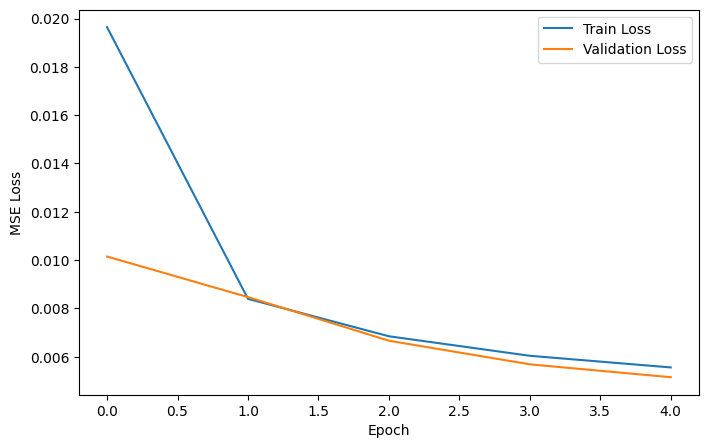

In [ ]:
plt.figure(figsize=(8, 5))

### START CODE HERE ###

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()

### END CODE HERE ###

plt.show()


# --- HOMELANDER: DON'T TOUCH IT!!
test_plot_train_losses_length = len(train_losses)
test_plot_val_losses_length = len(val_losses)
test_plot_train_loss_first = round(float(train_losses[0]), 6)
test_plot_train_loss_last = round(float(train_losses[-1]), 6)
test_plot_val_loss_first = round(float(val_losses[0]), 6)
test_plot_val_loss_last = round(float(val_losses[-1]), 6)


In [ ]:
ae.load_state_dict(
    torch.load(
        "best_ae.pth",
        map_location=device
    )
)
ae.eval()
print("Best model loaded.")

Best model loaded.


<div dir='rtl'>

### مشاهده تصاویر بازسازی‌شده

در این بخش می‌خواهیم عملکرد Autoencoder را به‌صورت بصری بررسی کنیم.

مراحل کار:
- یک batch از `test_loader` بگیرید.
- فقط 8 تصویر اول را انتخاب کنید.
- مدل را بدون محاسبه گرادیان اجرا کنید تا تصاویر بازسازی‌شده تولید شوند.
- تصاویر اصلی و بازسازی‌شده را در یک شکل `2×8` نمایش دهید:
  - ردیف اول: تصاویر اصلی
  - ردیف دوم: تصاویر بازسازی‌شده

### نکته
برای نمایش تصویر با `matplotlib`:
- باید tensor را از GPU به CPU منتقل کنید.
- ترتیب ابعاد تصویر را از `(C, H, W)` به `(H, W, C)` تغییر دهید.
- محورهای هر subplot را خاموش کنید.


</div>

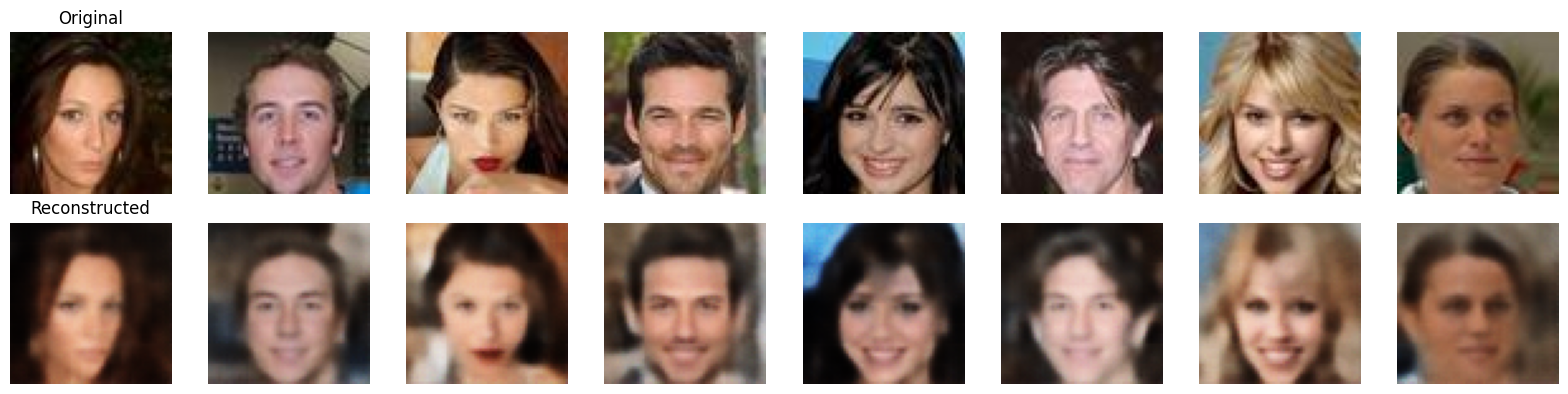

In [ ]:
### START CODE HERE ###

images = next(iter(test_loader))[:8].to(device)

ae.eval()

with torch.no_grad():
    recon = ae(images)

images = images.cpu()
recon = recon.cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i in range(8):
    axes[0, i].imshow(images[i].permute(1, 2, 0))
    axes[0, i].axis("off")

    axes[1, i].imshow(recon[i].permute(1, 2, 0))
    axes[1, i].axis("off")

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")

plt.tight_layout()
plt.show()

### END CODE HERE ###



# --- HOMELANDER: DON'T TOUCH IT!!
recon_vis_num_images = 8
recon_vis_input_shape = list(images.shape)
recon_vis_output_shape = list(recon.shape)

recon_vis_input_min = round(float(images.min().item()), 6)
recon_vis_input_max = round(float(images.max().item()), 6)

recon_vis_output_min = round(float(recon.min().item()), 6)
recon_vis_output_max = round(float(recon.max().item()), 6)


<div dir='rtl'>

`HOMELANDER`:
## لطفا سلول پایین را تغییر ندهید.

خروجی این فایل رو میتونید برای بات ارسال کنید. (اگه دوست دارید)

</div>

In [ ]:
submission = {}

# Dataset
submission["test_dataset_count"] = test_dataset_count

submission["test_train_count"] = test_train_count
submission["test_val_count"] = test_val_count
submission["test_test_count"] = test_test_count
submission["test_split_seed"] = test_split_seed


submission["test_image_size"] = test_image_size
submission["test_train_transform_names"] = test_train_transform_names
submission["test_test_transform_names"] = test_test_transform_names
submission["test_train_flip_p"] = test_train_flip_p


submission["test_dataset_class_train_len"] = test_dataset_class_train_len
submission["test_dataset_class_val_len"] = test_dataset_class_val_len
submission["test_dataset_class_test_len"] = test_dataset_class_test_len


submission["test_train_loader_shuffle"] = test_train_loader_shuffle
submission["test_train_batches_count"] = test_train_batches_count
submission["test_val_batches_count"] = test_val_batches_count
submission["test_test_batches_count"] = test_test_batches_count

submission["test_batch_images_shape"] = test_batch_images_shape

submission["test_stats_shape"] = test_stats_shape
submission["test_stats_min"] = test_stats_min
submission["test_stats_max"] = test_stats_max

submission["test_global_mean"] = test_global_mean
submission["test_global_std"] = test_global_std
submission["test_n_samples"] = test_n_samples

# Model
submission["test_total_params"] = test_total_params
submission["ae_num_encoder_layers"] = len(ae.encoder)
submission["ae_num_decoder_layers"] = len(ae.decoder)

submission["ae_encoder_layer_types"] = [
    type(layer).__name__ for layer in ae.encoder
]

submission["ae_decoder_layer_types"] = [
    type(layer).__name__ for layer in ae.decoder
]


submission["test_plot_train_losses_length"] = test_plot_train_losses_length
submission["test_plot_val_losses_length"] = test_plot_val_losses_length
submission["test_plot_train_loss_first"] = test_plot_train_loss_first
submission["test_plot_train_loss_last"] = test_plot_train_loss_last
submission["test_plot_val_loss_first"] = test_plot_val_loss_first
submission["test_plot_val_loss_last"] = test_plot_val_loss_last



In [ ]:

import json
with open('data.json', 'w', encoding='utf-8') as f:
    json.dump(submission, f, ensure_ascii=False, indent=4)


<div dir='rtl'>

# بخش دوم

</div>

<div dir='rtl'>

## تسک :۱ ساخت VAE با بتای متغیر

</div>

<div dir='rtl'>

## تسک :۲ نمایش تصاویر بازتولید شده

</div>

<div dir='rtl'>

## تسک :۳ تولید تصاویر جدید

</div>

<div dir='rtl'>

## تسک :۴ تبدیل یک عکس به عکس دیگر

</div>

<div dir='rtl'>

# تولید موسیقی کلاسیک - اختیاری

خروجی با کیفیت معیار نمره دهی است.
</div>